In [25]:
using ControlSystems
using LinearAlgebra
using Plots  

In [26]:
m = 0.2; M = 2.0; g = 9.81; l = 3

A = [0 1 0 0;
     0 0 m*g/M 0;
     0 0 0 1;
     0 0 (M+m)*g/(l*M) 0]

B = [0; 1/M; 0; 1/(l*M)]

4-element Vector{Float64}:
 0.0
 0.5
 0.0
 0.16666666666666666

In [27]:
using ForwardDiff

xdot((x1, x2, x3, x4)) = [x2;
                          (m*sin(x3)*(g*cos(x3)-l*(x4^2)))/(M+m*(sin(x3)^2));
                          x4;
                          ((M+m)*g*sin(x3)-m*l*(x4^2)*cos(x3)*sin(x3))/(l*(M+m*(sin(x3)^2)))]
x_stat1(x1) = [x1;
               0;
               0;
               0]

x_stat2(x1) = [x1;
               0;
               pi;
               0]
    
x_up = xdot(x_stat1(1)) #pendulum up
x_down = xdot(x_stat2(1)) #pendulum down

jac_up = ForwardDiff.jacobian(xdot, x_stat1(1))
jac_down = ForwardDiff.jacobian(xdot, x_stat2(1))
eigenvals_up = ForwardDiff.eigen(jac_up)
eigenvals_down = ForwardDiff.eigen(jac_down)

println("Unstable stationary point: ", Tuple(eigenvals_up.values))
println("Stable stationary point: ", Tuple(eigenvals_down.values))

Unstable stationary point: (-1.8965758619153628, 0.0, 0.0, 1.8965758619153625)
Stable stationary point: (0.0 - 1.8965758619153625im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 1.8965758619153625im)


In [28]:
Q_control = [B A*B A^2*B A^3*B]
d_numeric = det(Q_control)
d_analytic = g^2/(l^4 * M^4)

println("Numericaly computed determinant of Qc: ", d_numeric)
println("Analytically computed determinant of Qc: ", d_analytic)
println("Their absolute difference: ", abs(d_numeric - d_analytic))

Numericaly computed determinant of Qc: 0.07425625000000004
Analytically computed determinant of Qc: 0.07425625000000001
Their absolute difference: 2.7755575615628914e-17


In [30]:
system= ss(A, B, I(4), 0)
Q = I
R = I 
K_lqr = lqr(system, Q, R)
println("K (LQR): ", K_lqr)
u(x, t) = -K_lqr * x          
t = 0:0.01:15
disturbance_radians = 1.5                  
disturbance_degrees = disturbance_radians*(180/pi)
x0 = [0.0, 0.0, disturbance_radians, 0.0]
      

res = lsim(system, u, t, x0=x0)
plt = Plots.plot(res, plotx=true, ploty=false, layout=1, sp=1,
                    lab=["x" "ẋ" "θ" "θ̇dot"], ylabel="State variables values", 
                    title="Starting disturbance of $(round(disturbance_degrees))°")

savefig("lqr$(round(Int, disturbance_degrees)).png")

K (LQR): [-1.0000000000002496 -3.393611123273259 73.16590561668392 39.369715969197614]


"/home/boobsson/Desktop/3. letnik FRI/MM/project/lqr86.png"

[ Info: Saved animation to /home/boobsson/Desktop/3. letnik FRI/MM/project/pendulum86.gif


Plots.AnimatedGif("/home/boobsson/Desktop/3. letnik FRI/MM/project/pendulum86.gif")
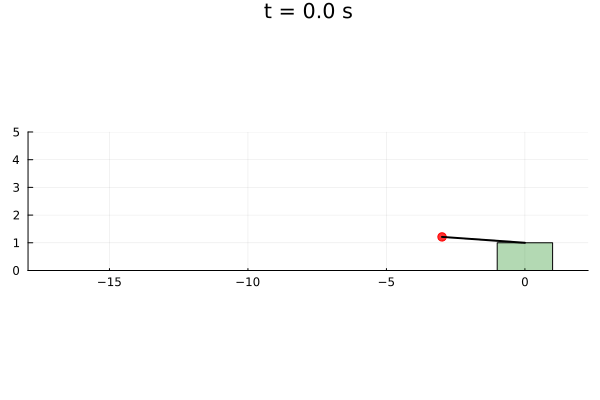

In [31]:
y_p(t) = 1+l*cos(t)
x_p(x,t) = x - l*sin(t)

#cart = Shape([-1, 1, 1, 0, -1], [0, 0, 1, 1, 1])
#p = plot(cart, legend=false, aspect_ratio=:equal, fillalpha=0, xlims=(-5, 5), ylims=(0,5))
#plot!(p, [0, 0], [1, 3], linecolor=:red)

time = res.t
xs = res.x[1,:]
x_left = minimum(xs)-2
x_right = maximum(xs)+2
xlimits = (x_left, x_right)
ylimits = (0, 5)
r = 0.15

animation = @animate for i in 1:length(time)
    x = res.x[1, i] #position of the cart at time i
    xdot = res.x[2, i] #velocitiy of the cart at time i
    theta = res.x[3, i] #angle of the pendulum at time i
    thetadot = res.x[4, i] #angular velocitiy of the pendulum at time i
    
    #coordinates of the pendulum at time i
    xp = x_p(x, theta)  
    yp = y_p(theta)
    
    #coordinates of the cart,  
    cart = Shape([x-1, x+1, x+1, x-1, x-1], [0, 0, 1, 1, 0])
    
    Plots.plot(cart,
        fill = true, fillalpha = 0.3, fillcolor = :green,
        linecolor = :black, legend = false,
        aspect_ratio = :equal,
        xlims = xlimits, ylims = ylimits, title="t = $(round(time[i], digits=2)) s")
    
    #circle at the top of the pendulum
    circle = Shape([xp + r*cos(θ) for θ in LinRange(0, 2pi, 200)], [yp + r*sin(θ) for θ in LinRange(0, 2pi, 200)])
    
    Plots.plot!(circle,
        fill = true, fillalpha = 0.8, fillcolor = :red,
        linecolor = :red)
    
    #pendulum
    Plots.plot!([x, xp], [1, yp], linecolor = :black, linewidth = 2)

end

gif(animation, "pendulum86.gif", fps=30)

In [32]:
"""
Stopped returns the time at which the pendulum settled.
It accepts results returned by ControlSystems.lsim function
which are given as a an object of which .x property returns a matrix of floats,
each row representing 1 state variable.
In my example this means 4 rows. Optional arguments are ϵ which sets the absolute difference
between angles/positions to be evaluated and time_interval specifies for how many steps in a row
that difference has to be smaller than ϵ.
"""
function stopped(res, h; ϵ_θ=1e-5,ϵ_x=1e-3, time_interval=30)
    for i in 1:length(res.t)
        if i > time_interval
            angles = res.x[3, i-time_interval:i]
            positions = res.x[1, i-time_interval:i]

            max_angle_change = maximum(abs.(diff(angles)))
            max_position_change = maximum(abs.(diff(positions)))

            if max_angle_change < ϵ_θ && max_position_change < ϵ_x
                println("Pendulum settled at $(round(i*h, digits=3)) seconds")
                return i
            end
        end
    end
    println("Pendulum did not settle")
    return length(res.t)*h
end

stopped

Pendulum settled at 10.1 seconds
Pendulum settled at 11.15 seconds
Pendulum settled at 11.64 seconds
Pendulum settled at 11.94 seconds
Pendulum settled at 12.16 seconds
Pendulum settled at 12.32 seconds
Pendulum settled at 12.44 seconds
Pendulum settled at 12.55 seconds
Pendulum settled at 12.63 seconds
Pendulum settled at 12.7 seconds


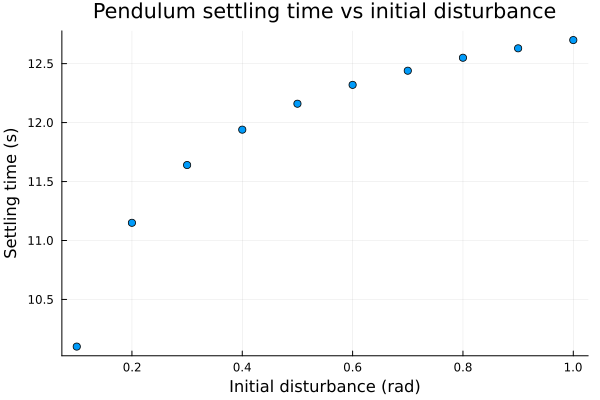

In [33]:
function run_disturbance(;epsilon=1e-5, time_intv=30, init_d = 0.1, h=0.01, plot = true, save = true)
    
    disturbances = [init_d*i for i in 1:10]
    stopping_times = []
    for d in disturbances
        x_test = [0, 0, d, 0]
        res_test = lsim(system, u, t, x0=x_test)
        d_d = round(d*(180/pi), digits=1)
        
        if plot 
            plt = Plots.plot(res_test, plotx=true, ploty=false, layout=1, sp=1,
                    lab=["x" "ẋ" "θ" "θ̇dot"], ylabel="State variables values", 
                    title="Starting disturbance of $(d_d)°", ylims=(-12, 3.5))
            #display(plt)
        end

        t_d = stopped(res_test, h, ϵ_θ=epsilon, time_interval=time_intv)
        push!(stopping_times, t_d*h)
        
        if save
            savefig("lqr$(d_d).png")
        end
    end

    return (S=stopping_times,D=disturbances) 
end

run = run_disturbance(plot=false, save=false)
stopping_times = run.S
disturbances = run.D
plt_time = Plots.scatter(disturbances, stopping_times,
                   xlabel="Initial disturbance (rad)",
                   ylabel="Settling time (s)",
                   title="Pendulum settling time vs initial disturbance",
                   legend=false)
display(plt_time)


Pendulum settled at 10.55 seconds
Pendulum settled at 11.6 seconds
Pendulum settled at 12.09 seconds
Pendulum settled at 12.39 seconds
Pendulum settled at 12.61 seconds
Pendulum settled at 12.77 seconds
Pendulum settled at 12.89 seconds
Pendulum settled at 13.0 seconds
Pendulum settled at 13.08 seconds
Pendulum settled at 13.15 seconds


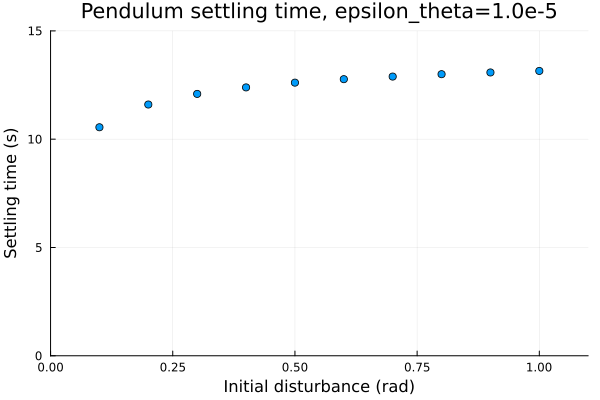

Pendulum settled at 7.53 seconds
Pendulum settled at 8.45 seconds
Pendulum settled at 9.46 seconds
Pendulum settled at 10.12 seconds
Pendulum settled at 10.55 seconds
Pendulum settled at 10.86 seconds
Pendulum settled at 11.1 seconds
Pendulum settled at 11.29 seconds
Pendulum settled at 11.46 seconds
Pendulum settled at 11.6 seconds


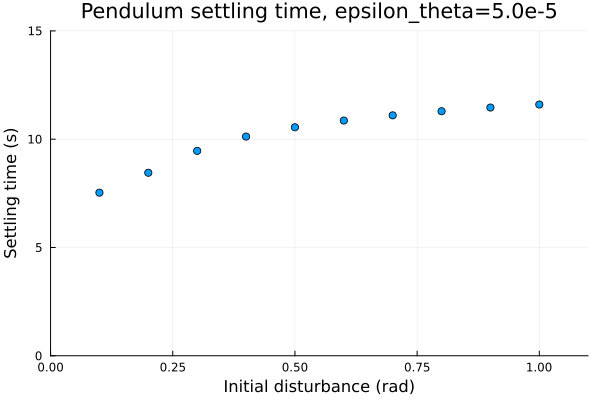

Pendulum settled at 7.53 seconds
Pendulum settled at 8.45 seconds
Pendulum settled at 8.89 seconds
Pendulum settled at 9.16 seconds
Pendulum settled at 9.34 seconds
Pendulum settled at 9.48 seconds
Pendulum settled at 9.59 seconds
Pendulum settled at 9.68 seconds
Pendulum settled at 9.75 seconds
Pendulum settled at 9.81 seconds


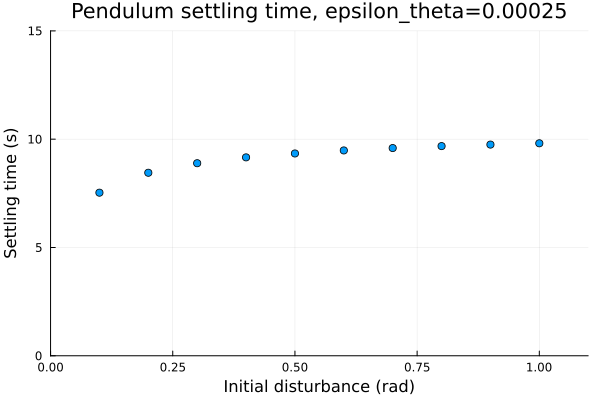

In [34]:
eps1 = [1e-5 * 5^i for i in 0:2]
for e in eps1
    r = run_disturbance(epsilon=e,time_intv=75, plot = false, save=false)
    st = r.S
    d = r.D  
    plt_time = Plots.scatter(d, st,
                   xlabel="Initial disturbance (rad)",
                   ylabel="Settling time (s)",
                   title="Pendulum settling time, epsilon_theta=$(e)",
                   legend=false, ylims=(0, 15), xlims=(0,d[end]+0.1))
    display(plt_time)
    savefig("time$(e).png")
end

In [35]:
#Phase portraits, only for θ and θdot
using CairoMakie
A_θ = A[3:4, 3:4] #Around equilibrium, we assume x approx 0, xdot approx 0

function vector_field(θ, θdot)
    #Linearized system -> A_θ*[θ, θdot]^T
    return Point2f(A_θ[1,1]*θ + A_θ[1,2]*θdot, A_θ[2,1]*θ + A_θ[2,2]*θdot) 
end

fig = Figure(size = (600, 500))
ax = Axis(fig[1,1], xlabel = "θ (rad)", ylabel = "θ̇ (rad/s)", title  = "Phase portrait around upright equilibrium")

#print(available_marker_symbols())
streamplot!(ax, vector_field, -0.5..0.5, -1.0..1.0, colormap  = :plasma,gridsize  = (32, 32), arrow_size = 12)
save("phase_portrait.png", fig)